In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, tracemalloc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib

In [3]:
df = pd.read_csv('/Users/toor/Documents/sem/DA_AI_ML/group_project/Data/adult.csv')

# Load shared splits

In [4]:
X_train, X_test, y_train, y_test = joblib.load('data/train_test_split.pkl')
preprocessor = joblib.load('data/preprocessor.pkl')

# Full pipeline with LR

In [5]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

 # Track runtime & memory

In [6]:
tracemalloc.start()
start = time.time()
lr_pipeline.fit(X_train, y_train)
train_time = time.time() - start
current, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Evaluate

In [7]:
y_pred = lr_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Training time: {train_time:.2f}s | Peak memory: {peak_mem / 1024:.2f} KB")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]):.4f}")

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4976
           1       0.72      0.58      0.64      1537

    accuracy                           0.85      6513
   macro avg       0.80      0.76      0.77      6513
weighted avg       0.84      0.85      0.84      6513

Training time: 0.24s | Peak memory: 15232.92 KB
ROC-AUC: 0.9042


# Saving model

In [8]:
joblib.dump(lr_pipeline, 'data/lr_model.pkl')
print("✅ Model saved!")

✅ Model saved!


# Confusion Matrix Plot

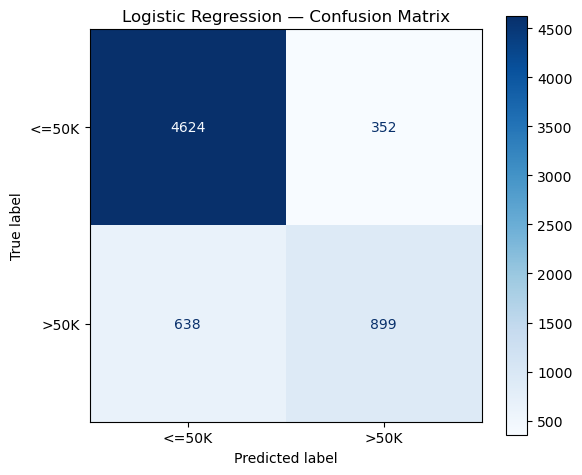

Confusion matrix saved!


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    lr_pipeline, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('data/lr_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")


# ROC Curve Plot

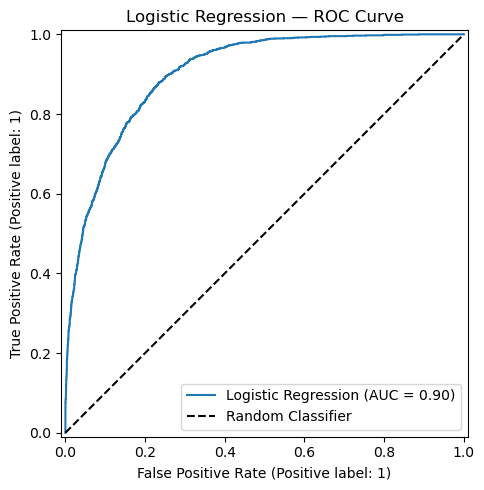

ROC curve saved!


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(
    lr_pipeline, X_test, y_test, ax=ax, name='Logistic Regression'
)
ax.set_title('Logistic Regression — ROC Curve')
ax.plot([0,1],[0,1],'k--', label='Random Classifier')
ax.legend()
plt.tight_layout()
plt.savefig('data/lr_roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved!")